# Phase 3 — Supervised Baseline Results

Aggregates every run in `artifacts/runs/` (today or earlier) and produces:
1. Metric comparison table (val + test for regression and classification)
2. Confusion matrix for the best classifier (by macro-F1)
3. Residual plot for the best regressor (by MAE)
4. Optuna study visualisations where available

The notebook only **reads** artefacts — it does not retrain. Run baselines first via
```
scripts\run.bat -m src.training.run_baseline --model {lr|gbm|mlp} --task {reg|cls} [--tune --n-trials N]
```

In [1]:
from __future__ import annotations
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[0] if (Path.cwd() / 'notebooks').exists() else Path.cwd().parents[0]
RUNS_DIR = PROJECT_ROOT / 'artifacts' / 'runs'
print('Runs dir:', RUNS_DIR)
print('Found runs:', sorted(p.name for p in RUNS_DIR.glob('*')) if RUNS_DIR.exists() else '<none>')

Runs dir: G:\miniproject2\cdss_vasopressor\artifacts\runs
Found runs: ['2026-04-24_gbm_cls_42', '2026-04-24_gbm_reg_42', '2026-04-24_lr_cls_42', '2026-04-24_lr_reg_42', '2026-04-24_mlp_cls_42', '2026-04-24_mlp_reg_42']


In [2]:
def _parse_run(run_dir: Path) -> dict | None:
    mpath = run_dir / 'metrics.json'
    cpath = run_dir / 'config.json'
    if not mpath.exists() or not cpath.exists():
        return None
    m = json.loads(mpath.read_text())
    c = json.loads(cpath.read_text())
    row = {
        'run': run_dir.name,
        'model': c['model'],
        'task': c['task'],
        'tune': c['tune'],
        'seed': c['seed'],
    }
    for split in ('val', 'test'):
        for k, v in m.get(split, {}).items():
            if isinstance(v, (int, float)):
                row[f'{split}_{k}'] = v
    return row

rows = []
if RUNS_DIR.exists():
    for rd in sorted(RUNS_DIR.iterdir()):
        if not rd.is_dir():
            continue
        parsed = _parse_run(rd)
        if parsed:
            rows.append(parsed)
summary = pd.DataFrame(rows)
summary

,run,model,task,tune,seed,val_accuracy,val_macro_f1,val_weighted_f1,val_top2_accuracy,val_ece,...,val_mae,val_rmse,val_r2,val_residual_mean,val_residual_std,test_mae,test_rmse,test_r2,test_residual_mean,test_residual_std
0,2026-04-24_gbm_cls_42,gbm,classification,True,42,0.662615,0.529917,0.676200,0.866480,0.027214,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-24_gbm_reg_42,gbm,regression,True,42,NaN,NaN,NaN,NaN,NaN,...,0.045506,0.088444,0.585207,-0.001322,0.088435,0.044209,0.091188,0.532392,0.000280,0.091188
2,2026-04-24_lr_cls_42,lr,classification,False,42,0.606578,0.463559,0.627012,0.814069,0.046697,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-04-24_lr_reg_42,lr,regression,False,42,NaN,NaN,NaN,NaN,NaN,...,0.066294,0.108754,0.372834,0.000304,0.108754,0.064824,0.110146,0.317753,-0.001609,0.110134
4,2026-04-24_mlp_cls_42,mlp,classification,True,42,0.632869,0.505963,0.654662,0.850020,0.081899,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026-04-24_mlp_reg_42,mlp,regression,True,42,NaN,NaN,NaN,NaN,NaN,...,0.041732,0.093699,0.534456,0.019896,0.091562,0.040832,0.096469,0.476666,0.019758,0.094424


## 1. Metric comparison tables

In [3]:
if not summary.empty:
    reg = summary[summary['task'] == 'regression'].sort_values('val_mae') if 'val_mae' in summary else pd.DataFrame()
    print('Regression (sorted by val_mae):')
    cols = [c for c in ['run','model','val_mae','val_rmse','val_r2','test_mae','test_rmse','test_r2'] if c in reg.columns]
    display(reg[cols] if cols else reg)
    cls = summary[summary['task'] == 'classification'].sort_values('val_macro_f1', ascending=False) if 'val_macro_f1' in summary else pd.DataFrame()
    print('Classification (sorted by val_macro_f1):')
    cols = [c for c in ['run','model','val_macro_f1','val_accuracy','val_top2_accuracy','val_ece','test_macro_f1','test_accuracy','test_top2_accuracy'] if c in cls.columns]
    display(cls[cols] if cols else cls)

Regression (sorted by val_mae):


,run,model,val_mae,val_rmse,val_r2,test_mae,test_rmse,test_r2
5,2026-04-24_mlp_reg_42,mlp,0.041732,0.093699,0.534456,0.040832,0.096469,0.476666
1,2026-04-24_gbm_reg_42,gbm,0.045506,0.088444,0.585207,0.044209,0.091188,0.532392
3,2026-04-24_lr_reg_42,lr,0.066294,0.108754,0.372834,0.064824,0.110146,0.317753


Classification (sorted by val_macro_f1):


,run,model,val_macro_f1,val_accuracy,val_top2_accuracy,val_ece,test_macro_f1,test_accuracy,test_top2_accuracy
0,2026-04-24_gbm_cls_42,gbm,0.529917,0.662615,0.866480,0.027214,0.529401,0.676072,0.874837
4,2026-04-24_mlp_cls_42,mlp,0.505963,0.632869,0.850020,0.081899,0.503816,0.641623,0.857641
2,2026-04-24_lr_cls_42,lr,0.463559,0.606578,0.814069,0.046697,0.454649,0.614227,0.813899


## 2. Confusion matrix — best classifier

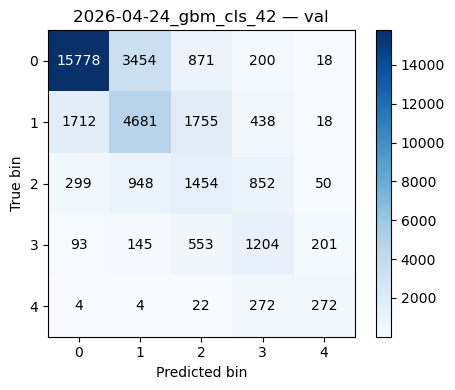

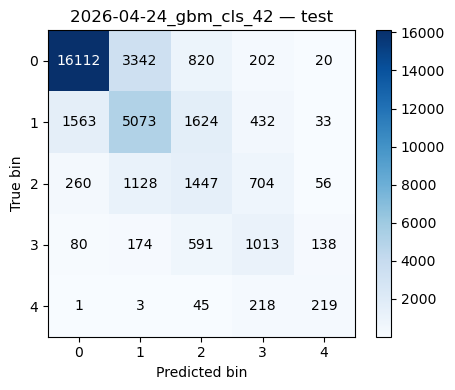

In [4]:
def _plot_confusion(cm: np.ndarray, title: str) -> None:
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xlabel('Predicted bin')
    ax.set_ylabel('True bin')
    ax.set_xticks(range(cm.shape[0]))
    ax.set_yticks(range(cm.shape[0]))
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[0]):
            ax.text(j, i, int(cm[i,j]), ha='center', va='center', color='black' if cm[i,j] < cm.max()/2 else 'white')
    fig.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()

if not summary.empty and 'val_macro_f1' in summary.columns:
    best_cls = summary[summary['task']=='classification'].sort_values('val_macro_f1', ascending=False).head(1)
    if not best_cls.empty:
        best_run = RUNS_DIR / best_cls.iloc[0]['run']
        mj = json.loads((best_run/'metrics.json').read_text())
        for split_name in ('val', 'test'):
            cm = np.array(mj[split_name].get('confusion_matrix', []))
            if cm.size:
                _plot_confusion(cm, f'{best_cls.iloc[0]["run"]} — {split_name}')

## 3. Residual plot — best regressor

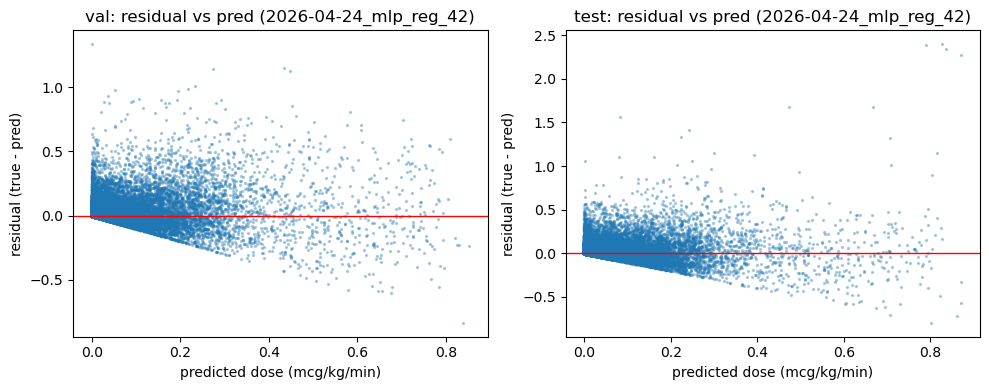

In [5]:
if not summary.empty and 'val_mae' in summary.columns:
    best_reg = summary[summary['task']=='regression'].sort_values('val_mae').head(1)
    if not best_reg.empty:
        best_run = RUNS_DIR / best_reg.iloc[0]['run']
        pred = pd.read_parquet(best_run / 'predictions.parquet')
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        for ax, fold in zip(axes, ['val', 'test']):
            sub = pred[pred['fold']==fold]
            ax.scatter(sub['y_pred'], sub['y_true'] - sub['y_pred'], s=2, alpha=0.3)
            ax.axhline(0, color='red', lw=1)
            ax.set_title(f'{fold}: residual vs pred ({best_reg.iloc[0]["run"]})')
            ax.set_xlabel('predicted dose (mcg/kg/min)')
            ax.set_ylabel('residual (true - pred)')
        plt.tight_layout(); plt.show()

## 4. Optuna study visualisations

G:\anaconda_envs\cdss_vasopressor\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== gbm_classification — 50 trials, best=0.5299 ===
{'learning_rate': 0.003855066856747697, 'num_leaves': 124, 'min_child_samples': 10, 'subsample': 0.9451879329452804, 'colsample_bytree': 0.7546034409700639, 'reg_alpha': 7.265259184516205e-05, 'reg_lambda': 0.03759230224635376}


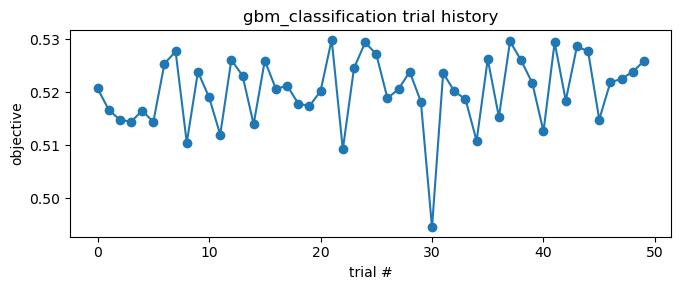

=== gbm_regression — 50 trials, best=-0.0455 ===
{'learning_rate': 0.009689537243827233, 'num_leaves': 214, 'min_child_samples': 29, 'subsample': 0.8876237117120844, 'colsample_bytree': 0.7364932637867576, 'reg_alpha': 9.31231297456399, 'reg_lambda': 1.5386763232396211e-06}


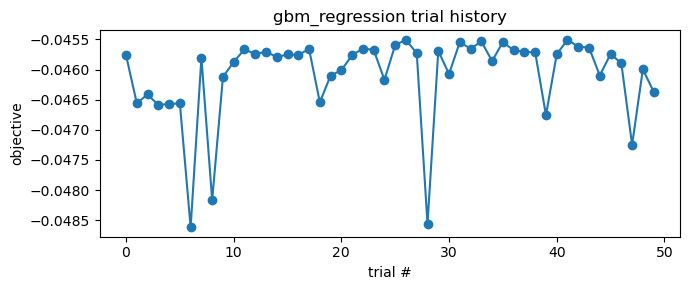

=== mlp_classification — 25 trials, best=0.5060 ===
{'n_layers': 1, 'hidden_0': 256, 'dropout': 0.27885681102411625, 'learning_rate': 0.006533305220227739, 'weight_decay': 9.935023909063694e-06, 'batch_size': 512, 'use_focal': True, 'focal_gamma': 1.3224425745080088}


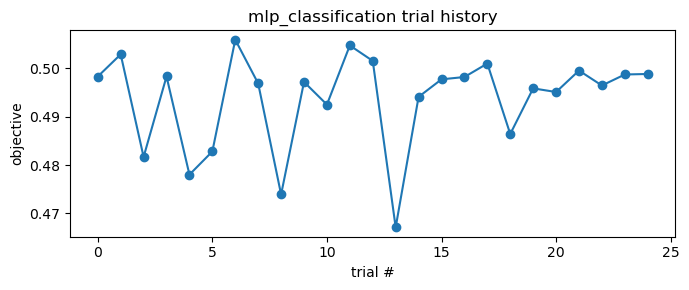

=== mlp_regression — 25 trials, best=-0.0417 ===


{'n_layers': 3, 'hidden_0': 256, 'hidden_1': 64, 'hidden_2': 64, 'dropout': 0.48914979518512725, 'learning_rate': 0.0004044758550598607, 'weight_decay': 3.5912972272153463e-06, 'batch_size': 512}


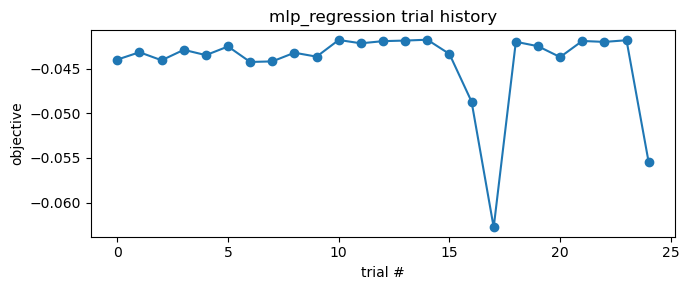

In [6]:
import optuna
OPTUNA_DIR = PROJECT_ROOT / 'artifacts' / 'optuna'
if OPTUNA_DIR.exists():
    for db in sorted(OPTUNA_DIR.glob('*.db')):
        name = db.stem  # e.g., 'gbm_cls'
        try:
            study = optuna.load_study(study_name=name, storage=f'sqlite:///{db.as_posix()}')
        except Exception as exc:
            print(f'{name}: {exc}'); continue
        print(f'=== {name} — {len(study.trials)} trials, best={study.best_value:.4f} ===')
        print(study.best_params)
        df = study.trials_dataframe()
        if not df.empty:
            fig, ax = plt.subplots(figsize=(7,3))
            ax.plot(df['number'], df['value'], 'o-')
            ax.set_xlabel('trial #'); ax.set_ylabel('objective'); ax.set_title(f'{name} trial history')
            plt.tight_layout(); plt.show()
else:
    print('No Optuna studies found at', OPTUNA_DIR)